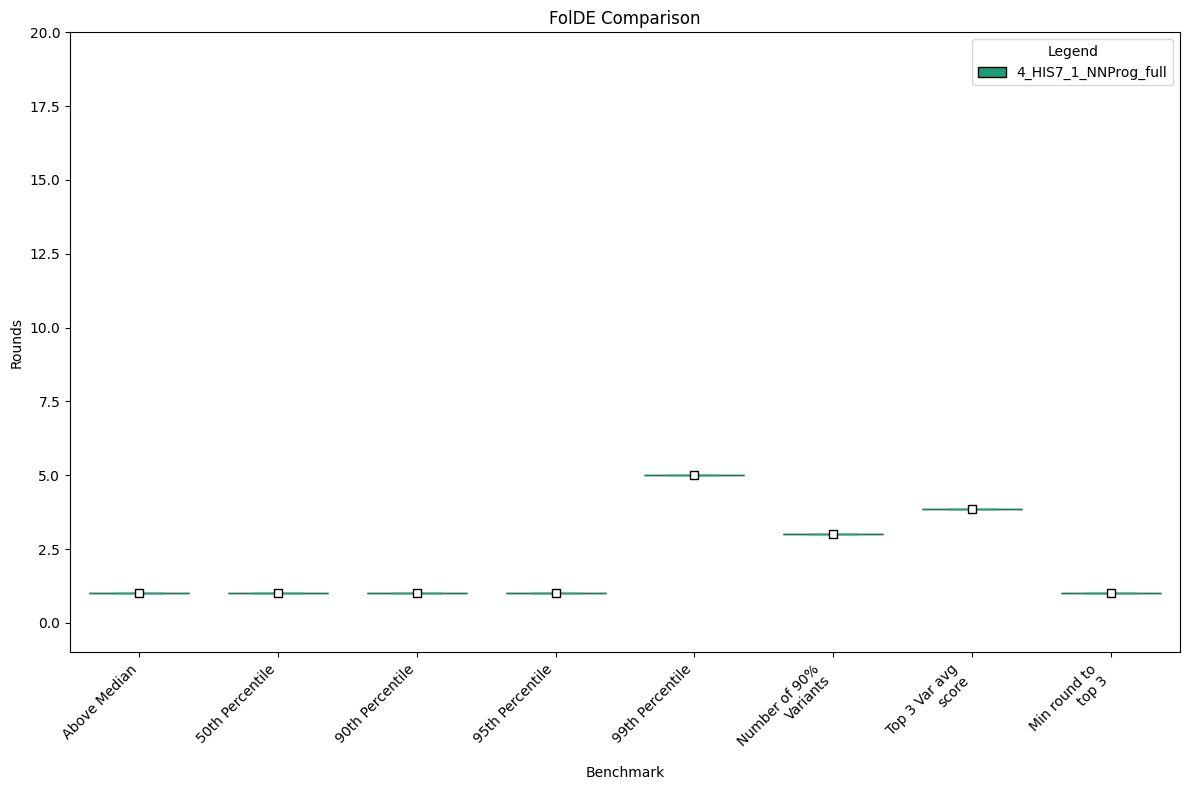

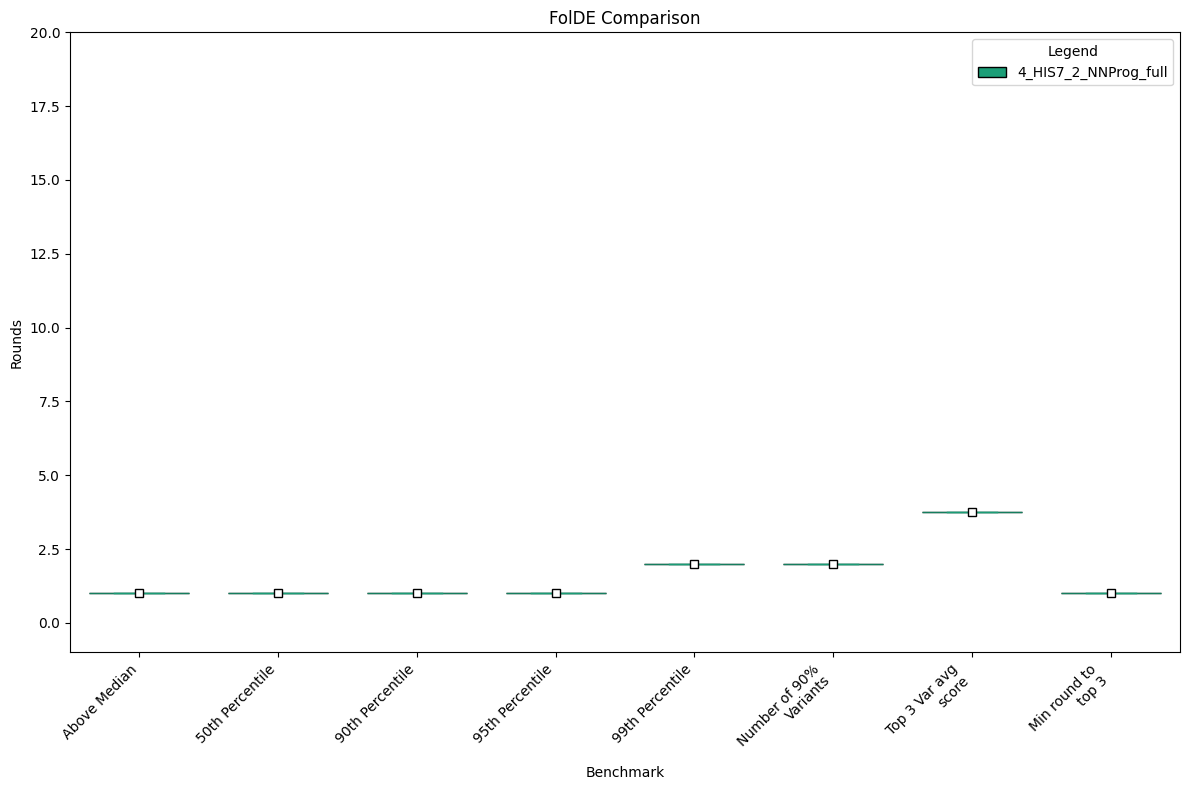

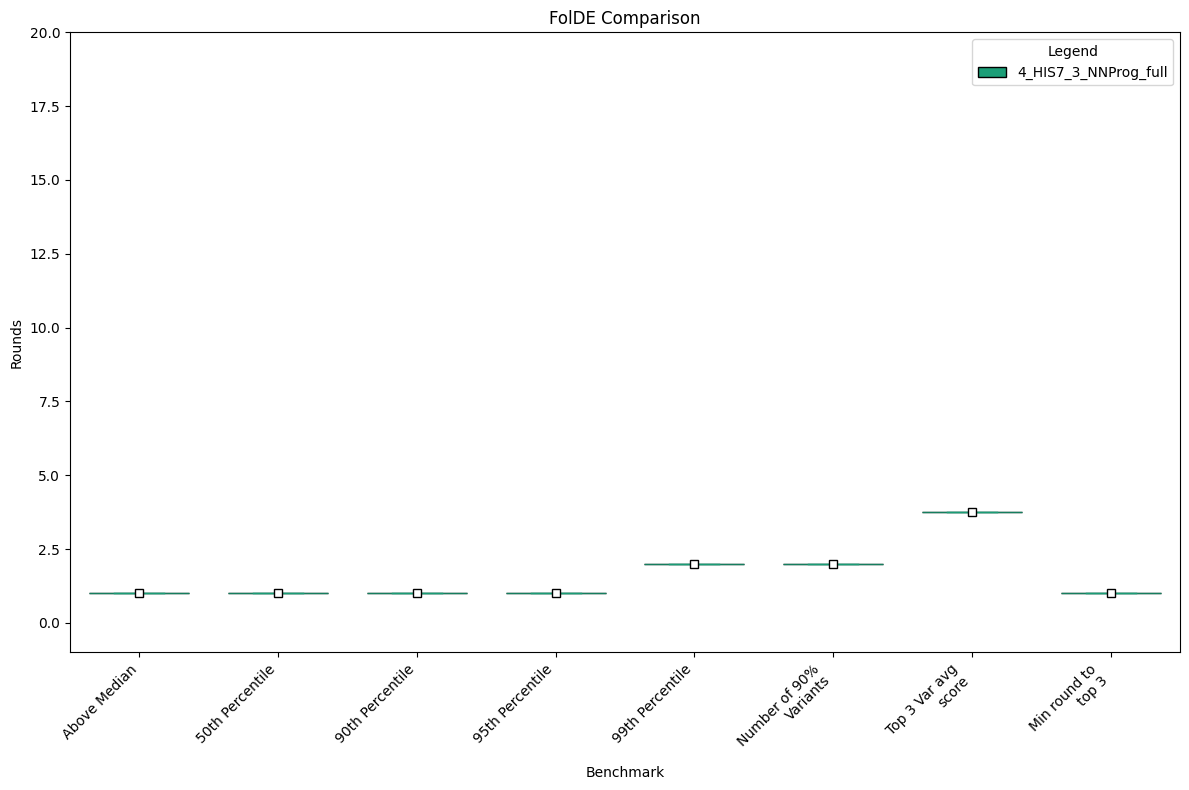

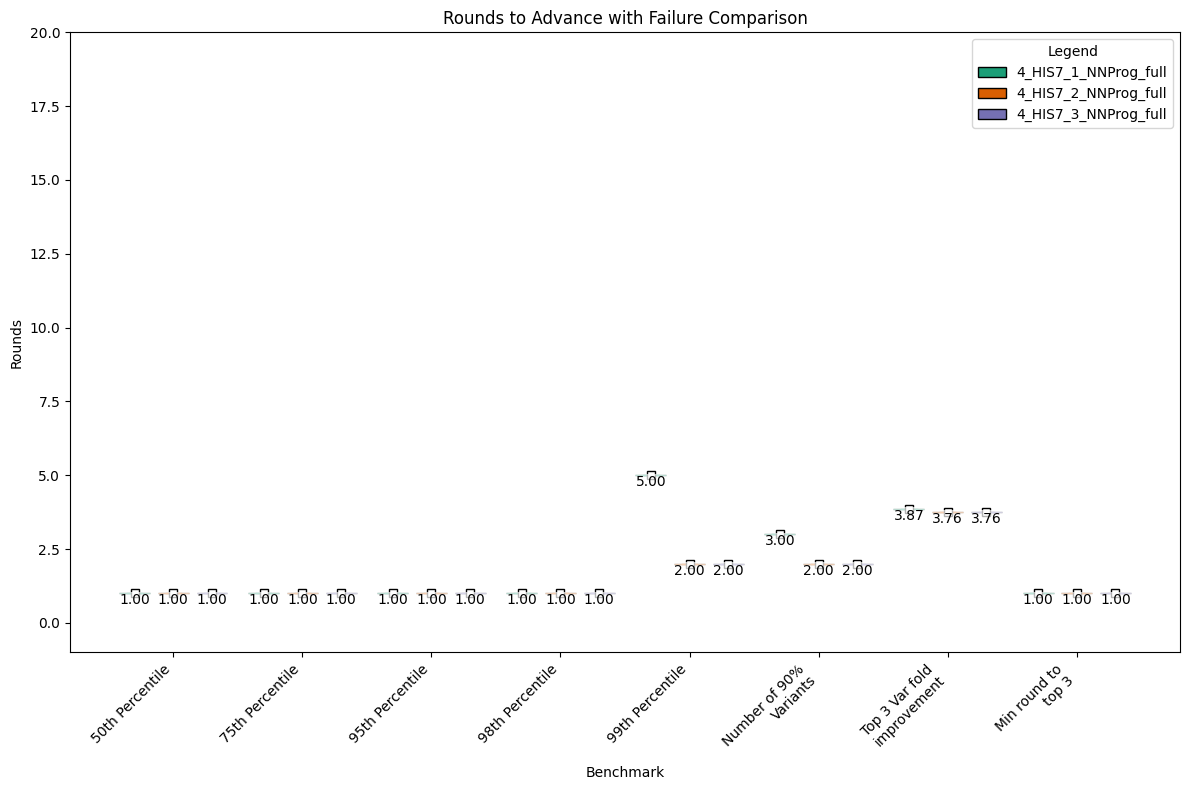

In [1]:
from evolve.evolvetest import digivolve_multi, plot_evolution_boxplot, optimize_memory_with_checks,normalize_dataset
import pandas as pd
from Bio import SeqIO
import os
import itertools
from IPython.display import clear_output
def get_stuff(prot_name):
    record = SeqIO.read(('../EvolveTest/wt_fasta/'+prot_name+'_WT.fasta'),"fasta")
    wt_aa_seq = str(record.seq)
    embeddings_dir = '../EvolveTest/' + prot_name
    embeddings_models = [
        'esmc_300m_multi',
        #'esmc_600m_multi'
    ]
    embeddings_paths = list(map(lambda x: ('embeddings/'+ prot_name + '_' + x + '.csv'),embeddings_models))

    
    return wt_aa_seq, embeddings_dir, embeddings_paths


benchmarks = {
        '50th Percentile' : 1,
        '75th Percentile' : 0.5,
        '95th Percentile' : 0.9,
        '98th Percentile' : 0.95,
        '99th Percentile' : 0,
        'Number of 90% Variants': 0,
        'Top 3 Var fold improvement': 0,
        'Min round to top 3': 0,
}
# Define all possible datasets
all_datasets = {
    'CLYGR': ('CLYGR', r'..\EvolveTest\DMS_data\DMS_ProteinGym_substitutions\D7PM05_CLYGR_Somermeyer_2022.xlsx', 12500),
    'AAV2S': ('AAV2S', r'..\EvolveTest\DMS_data\DMS_ProteinGym_substitutions\CAPSD_AAV2S_Sinai_2021.xlsx', -1.2),
    'HIS7': ('HIS7', r'..\EvolveTest\DMS_data\DMS_ProteinGym_substitutions\HIS7_YEAST_Pokusaeva_2019.xlsx', 0.3),
    #'TTGR_4Hy': ('TTGR',r'..\EvolveTest\DMS_data\DMS_ProteinGym_substitutions\ttgr_4Hy_NIshi_ttgr_filt.xlsx',1.27),
    #'TTGR_EllA': ('TTGR',r'..\EvolveTest\DMS_data\DMS_ProteinGym_substitutions\ttgr_EllA_NIshi_ttgr_filt.xlsx',1.08),
    #'TTGR_End': ('TTGR',r'..\EvolveTest\DMS_data\DMS_ProteinGym_substitutions\ttgr_End_NIshi_ttgr_filt.xlsx',1.93),
    #'TTGR_Nal': ('TTGR',r'..\EvolveTest\DMS_data\DMS_ProteinGym_substitutions\ttgr_Nal_NIshi_ttgr_filt.xlsx',1.08),
    #'TTGR_Nar': ('TTGR',r'..\EvolveTest\DMS_data\DMS_ProteinGym_substitutions\ttgr_Nar_NIshi_ttgr_filt.xlsx',4.83),
    #'TTGR_Ndes': ('TTGR',r'..\EvolveTest\DMS_data\DMS_ProteinGym_substitutions\ttgr_Ndes_NIshi_ttgr_filt.xlsx',1.61),
    #'TTGR_Phlo': ('TTGR',r'..\EvolveTest\DMS_data\DMS_ProteinGym_substitutions\ttgr_Phlo_NIshi_ttgr_filt.xlsx',5.53),
    #'TTGR_Quin': ('TTGR',r'..\EvolveTest\DMS_data\DMS_ProteinGym_substitutions\ttgr_Quin_NIshi_ttgr_filt.xlsx',1.10),
    #'TTGR_Tam': ('TTGR',r'..\EvolveTest\DMS_data\DMS_ProteinGym_substitutions\ttgr_Tam_NIshi_ttgr_filt.xlsx',1.73),
    #'RASK_binding': ('RASK',r'..\EvolveTest\DMS_data\DMS_ProteinGym_substitutions\RASK_HUMAN_Weng_2022_binding-DARPin_K55.xlsx',-0.460545526), 
    ##max2
    #'RASK_abundance': ( 'RASK',r'..\EvolveTest\DMS_data\DMS_ProteinGym_substitutions\RASK_HUMAN_Weng_2022_abundance.xlsx',-0.504113408), 
    ##max2
    #'GRB2': ('GRB2', r'..\EvolveTest\DMS_data\DMS_ProteinGym_substitutions\GRB2_HUMAN_Faure_2021.xlsx', -0.7),
    ##max 2
    #'SPG1': ('SPG1', r'..\EvolveTest\DMS_data\DMS_ProteinGym_substitutions\SPG1_STRSG_Olson_2014(2).xlsx', -4),
    ##max 2
    #'brenan_DOX':('brenan',r'..\EvolveTest\DMS_data\brenan_DOX_dms.xlsx', 1),
    #'brenan_SCH':('brenan',r'..\EvolveTest\DMS_data\brenan_SCH_dms.xlsx', 1),
    #'brenan_VRT':('brenan',r'..\EvolveTest\DMS_data\brenan_VRT_dms.xlsx', 1)

}
layers = [100,50]
rounds_evo = 10
num_var = 16
for dataset_id, data in all_datasets.items():
    protein_code = data[0]
    exp_activity_file_path = data[1]
    wt_activity = data[2]
    # Get necessary data for processing (do this once per protein)
    wt_aa_seq, embeddings_dir, embeddings_paths = get_stuff(protein_code)
    logits_path = os.path.join(embeddings_dir, 'embeddings', f'logits_{protein_code}_wt_melted.csv')
    raw_exp_activity_df = pd.read_excel(exp_activity_file_path)
    raw_exp_activity_df = optimize_memory_with_checks(raw_exp_activity_df)
    #exp_activity_df = raw_exp_activity_df.sort_values('activity', ascending=False)
    raw_exp_activity_df['activity'] = normalize_dataset(raw_exp_activity_df['activity'], wt_activity)
    logits_df = pd.read_csv(logits_path)
    embeddings_path = os.path.join(embeddings_dir, embeddings_paths[0])
    raw_embedding_df = pd.read_csv(embeddings_path)
    # Then iterate through rounds
    #for pair in itertools.combinations(range(1, 3), 2):
    for depth in range(4,5):
        scope = 1
        results = pd.DataFrame()
        for rounds_to_advance in range(1, 4):
            depth = depth
            # Determine which variable to use
            #if rounds_to_advance > depth:
            #    continue
            if rounds_to_advance:
                if scope != 1:
                    continue
                variable = 'NNProg_full'
            else:
                variable = scope
            
            # Create dataset name
            dataset_name = f'{depth}_{dataset_id}_{rounds_to_advance}_{variable}'
            #print(dataset_name)
            # Run the digivolve function
            result = digivolve_multi(
                wt_aa_seq, protein_code,
                wt_activity, dataset_name,
                raw_exp_activity_df,raw_embedding_df,
                embeddings_dir, embeddings_paths,
                num_var, layers,
                logits_df, scope, depth,
                progressive = rounds_to_advance,
                full=True,
                # cloning_failure = 0.666, show=True
            )
            
            # Append results
        
            results = pd.concat([results, result], axis=1)
        clear_output(wait=True)
        results.to_excel(os.path.join(embeddings_dir,f"{depth}_depth_{dataset_id}_{variable}.xlsx"))
        results_name = os.path.join(embeddings_dir,f"{depth}_depth_{dataset_id}_{variable}")
        plot_evolution_boxplot(results, benchmarks, new_variable='Rounds to Advance with Failure',
                               save_path=(results_name),
                               show=True,color_by_count=True,label='mean')
    

AmiE_Acet_100_iter


Processing AmiE_Acet_100_iter:   0%|          | 0/1 [00:00<?, ?it/s]

Evolution rounds for embeddings/amiE_esmc_300m_WT.csv:   0%|          | 0/1 [00:00<?, ?it/s]

Evolution Progress:   0%|          | 0/20 [00:00<?, ?it/s]

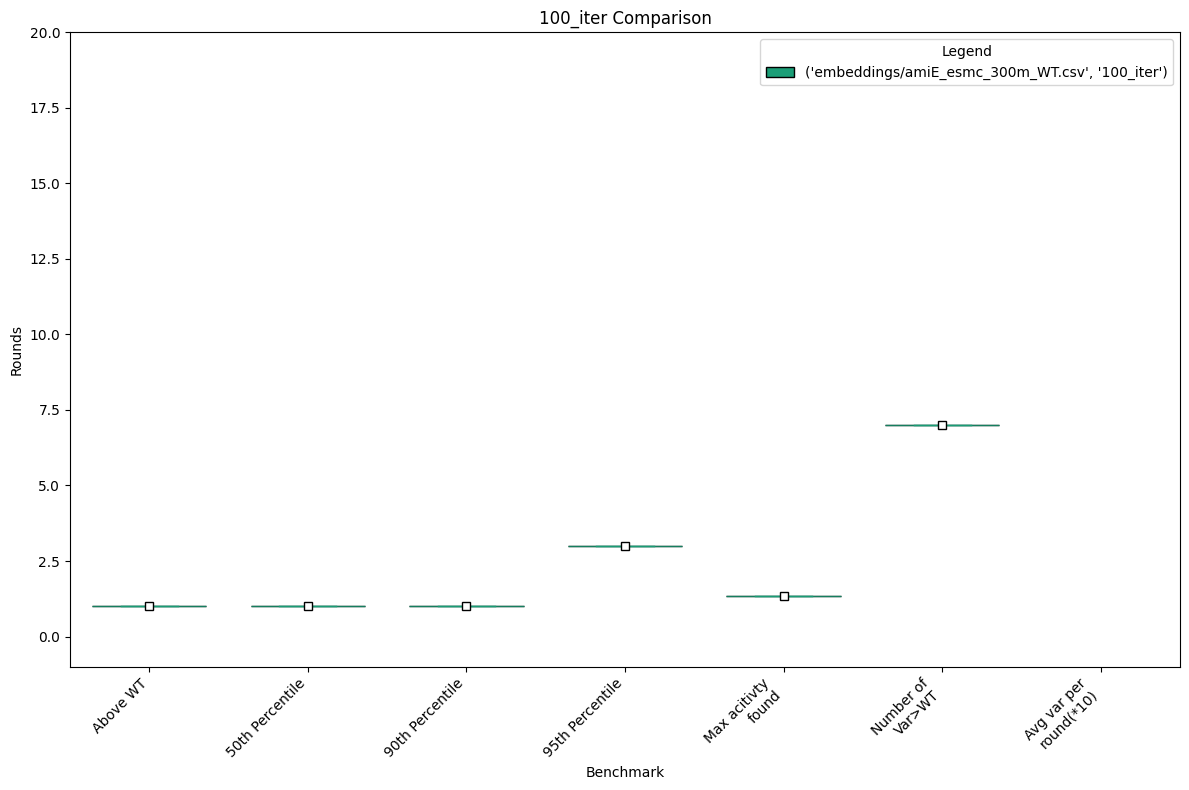

AmiE_Isobut_100_iter


Processing AmiE_Isobut_100_iter:   0%|          | 0/1 [00:00<?, ?it/s]

Evolution rounds for embeddings/amiE_esmc_300m_WT.csv:   0%|          | 0/1 [00:00<?, ?it/s]

Evolution Progress:   0%|          | 0/20 [00:00<?, ?it/s]

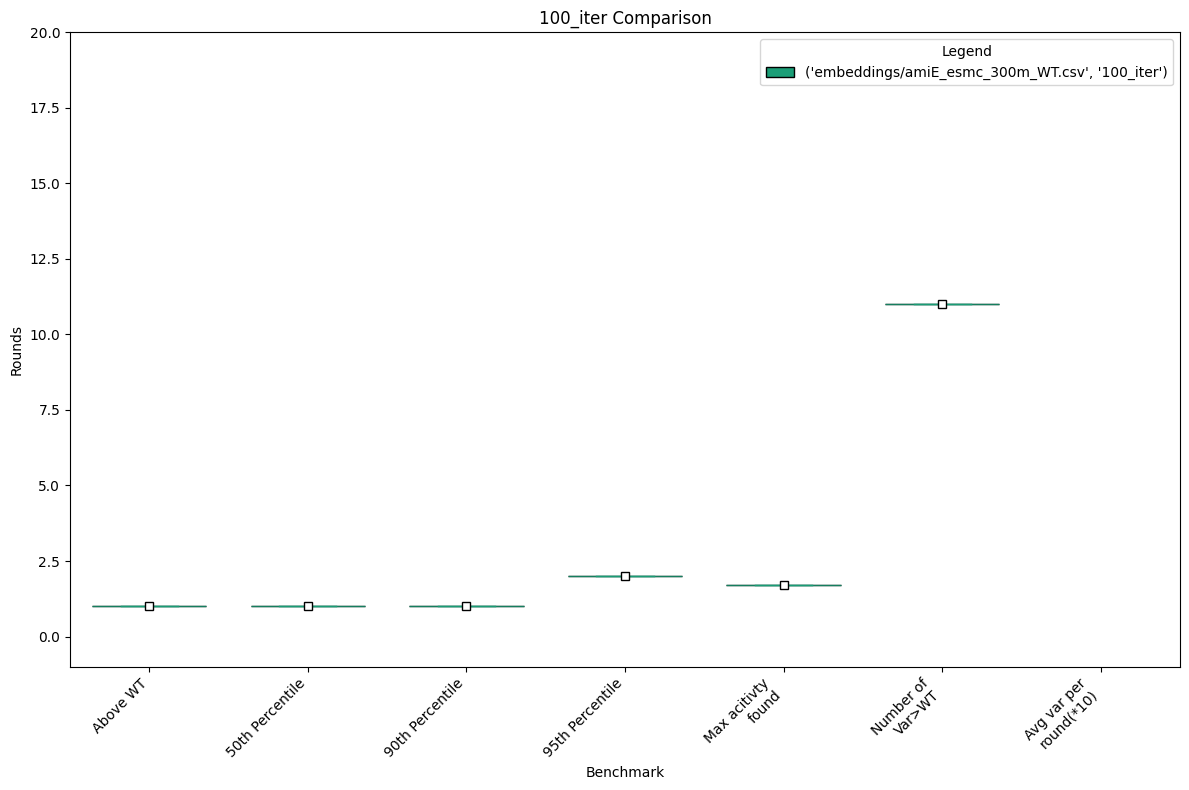

AmiE_Propi_100_iter


Processing AmiE_Propi_100_iter:   0%|          | 0/1 [00:00<?, ?it/s]

Evolution rounds for embeddings/amiE_esmc_300m_WT.csv:   0%|          | 0/1 [00:00<?, ?it/s]

Evolution Progress:   0%|          | 0/20 [00:00<?, ?it/s]

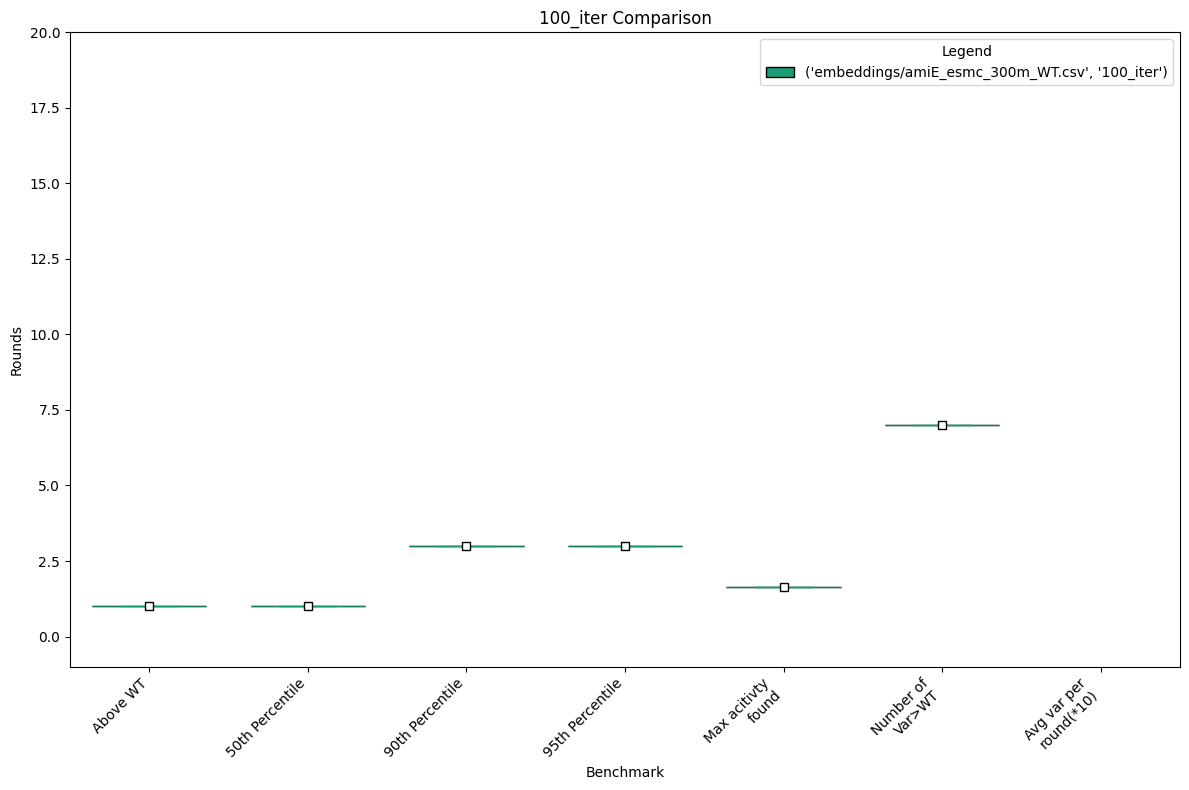

In [ ]:
from evolve.evolvetest import digivolveZS
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor, StackingRegressor, ExtraTreesRegressor
from sklearn.svm import SVR
from sklearn.neural_network import MLPRegressor
from evolve.ranked_mlp import MLPRegressorWithRankedLoss
from Bio import SeqIO
import os
def get_stuff(prot_name):
    record = SeqIO.read(('../EvolveTest/wt_fasta/'+prot_name+'_WT.fasta'),"fasta")
    wt_aa_seq = str(record.seq)
    embeddings_dir = '../EvolveTest/' + prot_name
    embeddings_models = [
        #'esm1b_t33_650M_UR50S',
        #'esm1v_t33_650M_UR90S_1',
        #'esm1v_t33_650M_UR90S_2',
        #'esm1v_t33_650M_UR90S_3',
        #'esm1v_t33_650M_UR90S_4',
        #'esm1v_t33_650M_UR90S_5',
        #'esm2_t48_15B_UR50D',
        'esmc_300m_WT',
        #'esmc_600m_WT'
    ]
    embeddings_paths = list(map(lambda x: ('embeddings/'+ prot_name + '_' + x + '.csv'),embeddings_models))

    
    return wt_aa_seq, embeddings_dir, embeddings_paths
randomforest = RandomForestRegressor(
        n_estimators=100,
        criterion="friedman_mse",
        max_depth=None,
        min_samples_split=2,
        min_samples_leaf=1,
        min_weight_fraction_leaf=0.0,
        max_features=1.0,
        max_leaf_nodes=None,
        min_impurity_decrease=0.0,
        bootstrap=True,
        oob_score=False,
        n_jobs=None,
        random_state=1,
        verbose=0,
        warm_start=False,
        ccp_alpha=0.0,
        max_samples=None,
    )
estimators = [
    ('mlp', MLPRegressor(random_state=1,hidden_layer_sizes=(500,100,50),max_iter=5000)),
    ('rfr', randomforest)
]
zero_shot = [
            #[0,0,16], #[marginal WT ranked, marginal top3 per locus, random]
            #[0,16,0],
            [16,0,0],
            #[8,8,0],
             ]
models = {
    'ExtraTrees' : ExtraTreesRegressor(criterion="friedman_mse",random_state=1),
    'RandomForest': randomforest,
    'GradientBoosting': GradientBoostingRegressor(random_state=1),
    'SVR': SVR(),
    'NeuralNet': MLPRegressor(random_state=1,max_iter=5000, 
                              #activation='logistic',
                              n_iter_no_change=200,
                              hidden_layer_sizes=(100,50)),
    'NeuralNetRL' : MLPRegressorWithRankedLoss(random_state=1, 
                                            hidden_layer_sizes=(100,50),
                                            #early_stopping=True,
                                            #tol=1e-4,
                                            #learning_rate_init=.001,
                                            max_iter=2000,verbose=True,
                                            #learning_rate='constant',
                                            n_iter_no_change=200,
                                            #activation='softplus',
                                            ),
    'StackingRegressor': StackingRegressor(estimators=estimators,
                                            final_estimator=SVR()),
    'NNStackingRegressor': StackingRegressor(estimators=estimators,
    final_estimator=MLPRegressorWithRankedLoss(random_state=1, hidden_layer_sizes=(500,100,50),max_iter=1000,verbose=True))
}

model = 'NNRLsoft'
new_variable = '100_full'
model_type = models['NeuralNet']
wt_activity = 1
rounds_evo =  10
num_var = 16
prot_name = 'amiE'
wt_aa_seq, embeddings_dir, embeddings_paths = get_stuff(prot_name)
logits_path = os.path.join(embeddings_dir,'embeddings',f'logits_{prot_name}_wt_melted.csv')
runs = {
    #f'zika_NN_500_rand':r'..\EvolveTest\DMS_data\zika_dms.xlsx',
    #f'rubisco_NN_full':r'..\EvolveTest\DMS_data\rubisco_dms.xlsx',
    f'AmiE_Acet_{new_variable}':r'..\EvolveTest\DMS_data\amie_Acet_dms.xlsx', 
    f'AmiE_Isobut_{new_variable}':r'..\EvolveTest\DMS_data\amie_Isobut_dms.xlsx',
    f'AmiE_Propi_{new_variable}':r'..\EvolveTest\DMS_data\amie_Propi_dms.xlsx',
    #f'Tem_2500_NN_{new_variable}':r'..\EvolveTest\DMS_data\bla_amp_2500_dms.xlsx',
    #f'Tem_cef_NN_{new_variable}':r'..\EvolveTest\DMS_data\bla_cefo_dms.xlsx',
    #f'brenan_DOX_{new_variable}':r'..\EvolveTest\DMS_data\brenan_DOX_dms.xlsx', 
    #f'brenan_SCH_{new_variable}':r'..\EvolveTest\DMS_data\brenan_SCH_dms.xlsx',
    #f'brenan_VRT_{new_variable}':r'..\EvolveTest\DMS_data\brenan_VRT_dms.xlsx',
    }

for name, dms_data in runs.items():
    dataset = name
    print(dataset)
    exp_activity_file_path = dms_data
    #plot_combined_landscape(exp_activity_file_path,embeddings_paths[-1],logits_path,prot_name)
    digivolveZS(wt_aa_seq,prot_name,
                          wt_activity,dataset,
                          exp_activity_file_path,
                          embeddings_dir, embeddings_paths,
                          num_var,rounds_evo,
                          model_type,
                          logits_path, zero_shot[0],new_variable,complete=True)

In [7]:
import pandas as pd
from evolve.evolvetest import plot_evolution_boxplot
import os
benchmarks = {
        '50th Percentile' : 1,
        '75th Percentile' : 0.5,
        '95th Percentile' : 0.9,
        '98th Percentile' : 0.95,
        '99th Percentile' : 0,
        'Number of >95% Variants': 0,
        'Top 3 percentile * 10': 0,
        'Avg round to top 3': 0,
        'Max Spearman': 0
}

df = pd.read_excel(r'..\EvolveTest\AAV2S\5_depth_AAV2S_rounds.xlsx')
#df.to_excel(os.path.join(embeddings_dir,f"{pair[1]}_depth_{protein_code}_{variable}.xlsx"))
print(df)
plot_evolution_boxplot(df, benchmarks, new_variable='Rounds to Advance',save_path=(os.path.join('..\EvolveTest\AAV2S',f"5_depth_AAV2S_rounds")),show=True,color_by_count=True)

   Unnamed: 0                                   1_AAV2S_5_rounds  \
0           0  [0, 0, 0, 1, None, 19, np.float64(9.84), np.fl...   
1           1  [0, 0, 0, 1, None, 14, np.float64(9.92), np.fl...   
2           2  [0, 0, 0, 1, 3, 10, np.float64(9.89), np.float...   
3           3  [0, 0, 0, 1, 10, 13, np.float64(9.91), np.floa...   
4           4  [0, 0, 1, 2, None, 13, np.float64(9.83), np.fl...   
5           5  [0, 0, 0, 1, None, 24, np.float64(9.86), np.fl...   
6           6  [0, 0, 1, 2, 12, 18, np.float64(9.94), np.floa...   
7           7  [0, 0, 0, 1, None, 18, np.float64(9.86), np.fl...   
8           8  [0, 0, 0, 1, None, 23, np.float64(9.8799999999...   
9           9  [0, 0, 0, 1, 5, 13, np.float64(9.86), np.float...   

                                    2_AAV2S_5_rounds  \
0  [0, 0, 0, 1, None, 26, np.float64(9.91), np.fl...   
1  [0, 0, 0, 1, None, 20, np.float64(9.84), np.fl...   
2  [0, 0, 0, 0, None, 27, np.float64(9.89), np.fl...   
3  [0, 0, 1, 1, None, 21, n